# Blocco della famiglia ad albero: albero potato, bagging, foresta, AdaBoost, gradient boosting

Questo notebook analizza il terzo blocco del confronto fra modelli sul dataset NASA C-MAPSS
(Turbofan Engine Degradation Simulation), nel quale la variabile da predire è la vita utile
residua di un motore aeronautico, espressa in cicli di funzionamento e censurata a 125 cicli.

I dati provengono dai file grezzi del NASA Prognostics Data Repository, collocati in `data/raw/`
e non versionati. Il perimetro sperimentale comprende i sottoinsiemi FD001 (un solo modo di
guasto) e FD003 (due modi di guasto), entrambi a regime operativo unico. Ogni riga della matrice
di progetto è un ciclo di funzionamento di un motore, descritto dal numero di ciclo, dalle
impostazioni operative e dalle letture dei sensori non costanti: 18 variabili su FD001 e 19 su
FD003.

## Cosa contiene questo notebook

I sei modelli confrontati qui condividono l'albero di decisione come unità costruttiva e si
distinguono per come lo impiegano. L'albero di regressione potato è un albero solo, la cui
complessità è governata da una penalizzazione sul numero di foglie. Bagging e foresta casuale
mediano molti alberi cresciuti per intero e adattati su campioni bootstrap, riducendo la varianza
della stima; la foresta aggiunge la decorrelazione, limitando le variabili candidate a ciascuna
divisione. AdaBoost, gradient boosting e la sua implementazione esterna sommano alberi poco
profondi adattati in sequenza sugli errori dei precedenti, riducendo la distorsione.

La domanda a cui il blocco risponde è se una relazione a soglie, costruita per partizioni
successive dello spazio delle variabili, colga qualcosa che le espansioni di base additive del
blocco precedente non colgono.

Il notebook non addestra modelli e non esegue lavoro computazionale: legge gli artefatti già
prodotti dallo script di esperimento e ne ricava figure, tabelle e lettura dei risultati. Può
quindi essere eseguito dall'inizio alla fine in pochi secondi, e gli stessi numeri che compaiono
qui esistono su disco in forma tabellare, indipendentemente dal notebook. L'unica eccezione è
l'albero potato, che viene caricato già adattato dallo script per poterne disegnare la struttura.

Gli artefatti letti sono prodotti da:

    python -m scripts.measure_tree_costs
    python -m scripts.run_tree_models

Il primo comando misura i costi e la saturazione degli insiemi e precede la scelta delle griglie;
il secondo esegue l'esperimento. Il confronto con i blocchi precedenti usa gli artefatti di
`python -m scripts.run_linear_models` e `python -m scripts.run_nonlinear_models`, già prodotti e
non rieseguiti qui.

## Protocollo sotto cui i risultati sono stati prodotti

Il partizionamento avviene per unità motore: tutte le righe di una stessa traiettoria restano
dalla stessa parte della verifica, perché cicli consecutivi dello stesso motore non sono
osservazioni indipendenti. Lo schema è un K-Fold con vincolo di gruppo a 5 fold, ripetuto su tre
semi. La ricerca degli iperparametri opera sulle 5 partizioni di un seme dedicato; la sola
configurazione selezionata viene poi rivalutata sulle 15 partizioni dei tre semi, e sono quei 15
punteggi a produrre media e dispersione riportate.

La metrica di riferimento è la radice dell'errore quadratico medio, nelle unità del target.
Errore assoluto medio e coefficiente di determinazione accompagnano la lettura e non partecipano
alla selezione. La standardizzazione è dentro la pipeline di tutti i modelli, anche di questi,
per i quali è irrilevante: gli alberi sono invarianti a trasformazioni monotone delle singole
variabili, e mantenerla evita di introdurre una differenza di condizioni fra famiglie confrontate.
L'unico effetto visibile è che le soglie di divisione dell'albero sono espresse in unità
standardizzate, e vanno riportate alle unità originali per essere lette.

La dispersione riportata è calcolata sui fold e non è l'errore standard della media: i fold
condividono le righe di addestramento. Due modelli il cui divario è inferiore alla dispersione
non sono distinguibili sotto questo protocollo e non vengono ordinati.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import plot_tree

# I percorsi sono ricavati dalla posizione del notebook, non dalla directory di lavoro, così
# che l'esecuzione non dipenda da dove viene avviato il kernel.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TREE_DIR = PROJECT_ROOT / "experiments" / "tree_models"
NONLINEAR_DIR = PROJECT_ROOT / "experiments" / "nonlinear_models"
LINEAR_DIR = PROJECT_ROOT / "experiments" / "linear_models"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

SUBSETS = ("FD001", "FD003")
MODELS = ("tree", "bagging", "random_forest", "adaboost", "gradient_boosting", "xgboost")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})


def load(directory, subset, name):
    return pd.read_csv(directory / f"{subset}_{name}.csv")


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{name}.png", bbox_inches="tight")


comparison = {s: load(TREE_DIR, s, "comparison") for s in SUBSETS}
folds = {s: load(TREE_DIR, s, "cv_folds") for s in SUBSETS}
grids = {s: load(TREE_DIR, s, "grids") for s in SUBSETS}
importances = {s: load(TREE_DIR, s, "importances") for s in SUBSETS}
permutation = {s: load(TREE_DIR, s, "permutation_importances") for s in SUBSETS}
diagnostics = {s: load(TREE_DIR, s, "diagnostics") for s in SUBSETS}
saturation = {s: load(TREE_DIR, s, "ensemble_saturation") for s in SUBSETS}

previous = {}
for s in SUBSETS:
    blocks = pd.concat([load(LINEAR_DIR, s, "comparison"), load(NONLINEAR_DIR, s, "comparison")],
                       ignore_index=True)
    previous[s] = blocks[~blocks["model"].str.startswith("baseline")]

LABELS = {row["model"]: row["label"] for s in SUBSETS for _, row in comparison[s].iterrows()}


def best_previous(subset):
    """Miglior modello dei due blocchi già conclusi, escluse le baseline."""
    table = previous[subset]
    return table.loc[table["rmse_mean"].idxmin()]


def selected_config(subset, model):
    """Configurazione selezionata, come dizionario dei parametri della griglia."""
    row = diagnostics[subset].query("model == @model")
    block = grids[subset].query("model == @model")
    if not len(block):
        return {}
    best = block.sort_values("rank_test_rmse").iloc[0]
    return {c: best[c] for c in block.columns if c.startswith("param_") and pd.notna(best[c])}

## 1. Confronto fra i modelli del blocco

I sei modelli vedono la stessa matrice, le stesse partizioni e lo stesso pre-processing dei
modelli dei due blocchi precedenti. Le due baseline sono ricalcolate qui e non riprese dagli
artefatti degli altri blocchi, così che la tabella sia prodotta interamente da una sola
esecuzione: la predizione costante è il pavimento assoluto, la regressione sul solo numero di
ciclo è il pavimento informativo.

La colonna con il numero di variabili attive conta quelle che il modello ha usato per almeno una
divisione. È l'analogo, per questa famiglia, dei coefficienti non annullati dei blocchi
precedenti, ed è informativa solo sull'albero singolo: gli insiemi, avendo centinaia di alberi,
usano quasi sempre tutte le variabili almeno una volta.

In [2]:
for subset in SUBSETS:
    table = comparison[subset][["label", "config", "n_nonzero", "rmse_mean", "rmse_std",
                                "divario_in_dispersioni", "mae_mean", "r2_mean"]]
    table.to_csv(TABLES_DIR / f"{subset}_confronto_blocco_alberi.csv", index=False)
    print(f"\n{subset}")
    print(table.to_string(index=False))


FD001
                               label                                            config  n_nonzero  rmse_mean  rmse_std  divario_in_dispersioni  mae_mean   r2_mean
                     Foresta casuale             max_features=0.33, min_samples_leaf=5       18.0  16.594991  1.461715                    0.00 11.576677  0.840062
                             XGBoost learning_rate=0.05, max_depth=3, n_estimators=300       17.0  16.701141  1.361245                    0.08 11.612537  0.838171
                   Gradient boosting learning_rate=0.05, max_depth=3, n_estimators=300       17.0  16.708522  1.365804                    0.08 11.623046  0.838022
                   Bagging di alberi                              nessun iperparametro       18.0  16.894467  1.435207                    0.21 11.621097  0.834308
                            AdaBoost max_depth=6, learning_rate=0.01, n_estimators=800       17.0  16.966400  1.265216                    0.27 12.244618  0.833147
        Albero 

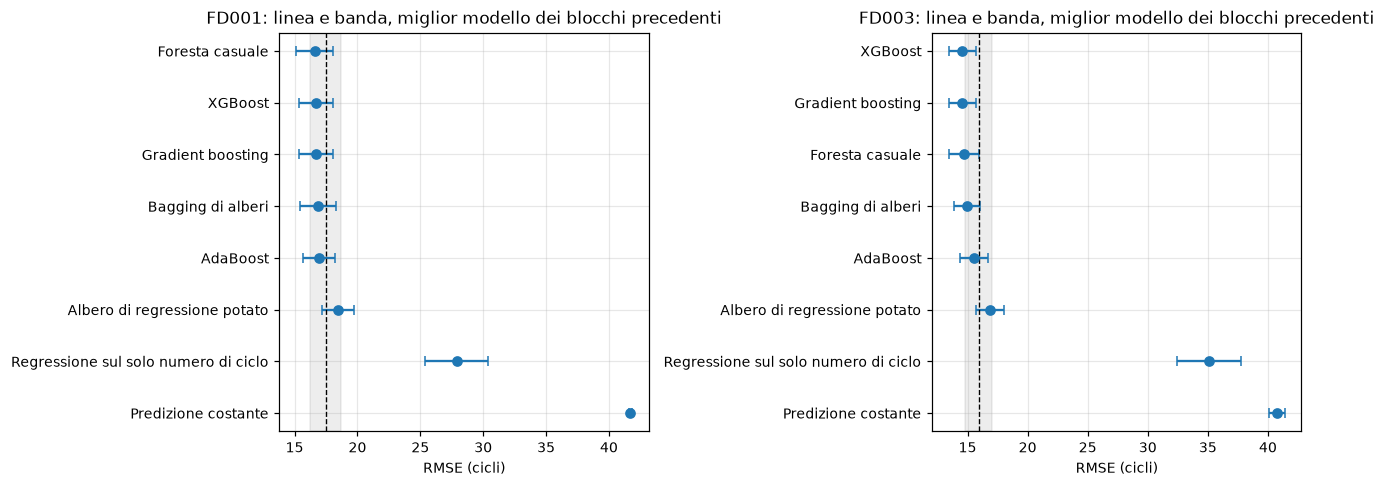

In [3]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(12, 4.5))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    table = comparison[subset].sort_values("rmse_mean", ascending=False)
    ax.errorbar(table["rmse_mean"], range(len(table)), xerr=table["rmse_std"], fmt="o", capsize=3)
    reference = best_previous(subset)
    ax.axvline(reference["rmse_mean"], color="black", linewidth=0.9, linestyle="--")
    ax.axvspan(reference["rmse_mean"] - reference["rmse_std"],
               reference["rmse_mean"] + reference["rmse_std"], color="black", alpha=0.07)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["label"])
    ax.set_xlabel("RMSE (cicli)")
    ax.set_title(f"{subset}: linea e banda, miglior modello dei blocchi precedenti")
save(fig, "confronto_blocco_alberi")
plt.show()

In [4]:
rows = []
for subset in SUBSETS:
    reference = best_previous(subset)
    for model in MODELS:
        row = comparison[subset].query("model == @model").iloc[0]
        scale = np.sqrt((row["rmse_std"] ** 2 + reference["rmse_std"] ** 2) / 2.0)
        rows.append({
            "sottoinsieme": subset,
            "modello": row["label"],
            "rmse": row["rmse_mean"],
            "dispersione": row["rmse_std"],
            "riferimento_precedente": reference["label"],
            "rmse_riferimento": reference["rmse_mean"],
            "guadagno_cicli": reference["rmse_mean"] - row["rmse_mean"],
            "guadagno_in_dispersioni": (reference["rmse_mean"] - row["rmse_mean"]) / scale,
        })
guadagno = pd.DataFrame(rows)
guadagno.to_csv(TABLES_DIR / "guadagno_su_blocchi_precedenti.csv", index=False)
guadagno

,sottoinsieme,modello,rmse,dispersione,riferimento_precedente,rmse_riferimento,guadagno_cicli,guadagno_in_dispersioni
0,FD001,Albero di regressione potato,18.480330,1.267815,Modello additivo generalizzato,17.462329,-1.018001,-0.822702
1,FD001,Bagging di alberi,16.894467,1.435207,Modello additivo generalizzato,17.462329,0.567863,0.428364
2,FD001,Foresta casuale,16.594991,1.461715,Modello additivo generalizzato,17.462329,0.867338,0.647240
3,FD001,AdaBoost,16.966400,1.265216,Modello additivo generalizzato,17.462329,0.495929,0.401219
4,FD001,Gradient boosting,16.708522,1.365804,Modello additivo generalizzato,17.462329,0.753807,0.585040
5,FD001,XGBoost,16.701141,1.361245,Modello additivo generalizzato,17.462329,0.761188,0.591877
6,FD003,Albero di regressione potato,16.870851,1.126531,Regression spline,15.914276,-0.956575,-0.860157
7,FD003,Bagging di alberi,14.938253,1.105120,Regression spline,15.914276,0.976024,0.886248
8,FD003,Foresta casuale,14.701185,1.214982,Regression spline,15.914276,1.213091,1.047831
9,FD003,AdaBoost,15.520888,1.176272,Regression spline,15.914276,0.393388,0.345820


La figura riporta la media sui 15 fold con la dispersione fra fold; la linea tratteggiata e la
banda grigia sono il miglior modello dei due blocchi già conclusi, cioè il livello che questo
blocco doveva superare per aggiungere qualcosa al confronto.

Tre letture, in ordine di robustezza.

I cinque insiemi non sono ordinabili fra loro. Il divario fra il primo e l'ultimo dei cinque è
una frazione di dispersione su entrambi i sottoinsiemi, e sotto questo protocollo non è
distinguibile: la famiglia non produce un vincitore, produce un plateau. Ciò che si legge non è
quale insieme sia migliore, ma che il modo di aggregare gli alberi conta poco rispetto al fatto di
aggregarli.

L'albero singolo è l'unico modello della famiglia che si stacca, indietro di più di una
dispersione su FD001 e di due su FD003. È la misura diretta di quanto l'aggregazione valga: la
stessa unità costruttiva, presa da sola, perde una quantità leggibile di accuratezza. Un albero
solo è una funzione a gradini con poche decine di livelli, adattata su una particolare
partizione dei dati, e la sua varianza rispetto al campione è alta.

Il guadagno sui blocchi precedenti è asimmetrico fra i due sottoinsiemi, e va detto con
precisione perché il solo confronto fra medie lo farebbe sembrare uniforme. La tabella lo esprime
in cicli e in unità di dispersione, che è la scala con cui il progetto decide se due misure
siano distinguibili.

## 2. Comportamento dei modelli lungo la griglia

Il punteggio del modello selezionato non dice se il minimo sia netto o se la curva sia piatta. La
distinzione conta: su una curva piatta la configurazione scelta è una fra molte equivalenti, e la
selezione non è un risultato stabile. Le curve riportano l'errore in cross-validation di ogni
configurazione esplorata, sulle 5 partizioni usate per la ricerca.

Le griglie hanno un numero diverso di assi, quindi le curve mostrano sezioni. Per l'albero l'asse
è unico ed è la penalizzazione sul numero di foglie. Per la foresta gli assi sono due e sono
entrambi rappresentati. Per i tre modelli per addizione la sezione fissa la profondità dell'albero
di base al valore selezionato e fa variare gli altri due assi: è la sezione che passa per la
configurazione scelta, non una scelta fra le sezioni possibili.

Il bagging non compare: non avendo iperparametri non ha griglia.

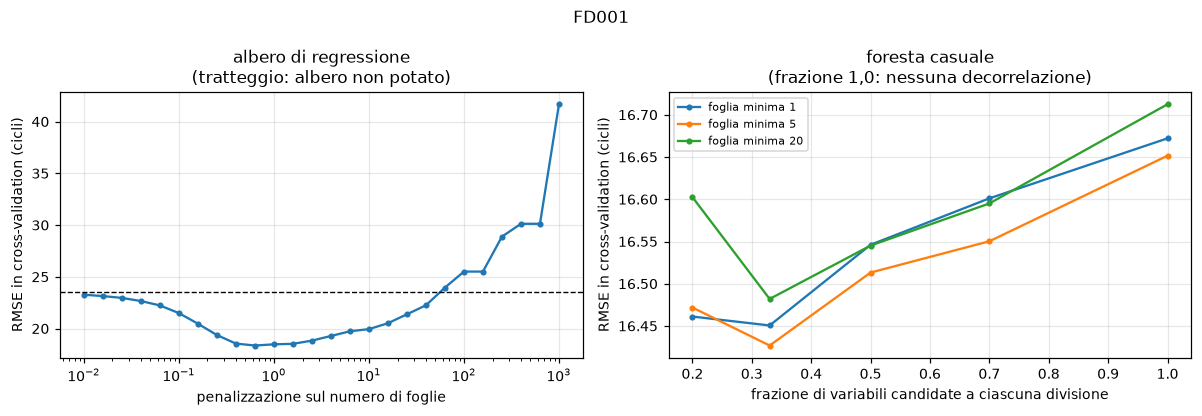

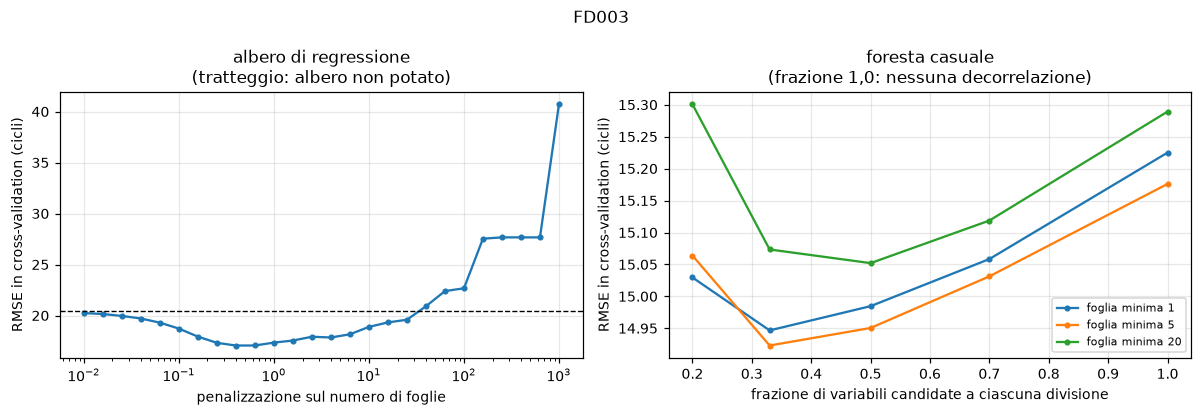

In [5]:
def grid_of(subset, model):
    block = grids[subset].query("model == @model").copy()
    return block.dropna(axis=1, how="all")


for subset in SUBSETS:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

    block = grid_of(subset, "tree").sort_values("param_model__ccp_alpha")
    unpruned = block[block["param_model__ccp_alpha"] == 0.0]["mean_test_rmse"]
    pruned = block[block["param_model__ccp_alpha"] > 0.0]
    axes[0].plot(pruned["param_model__ccp_alpha"], pruned["mean_test_rmse"], marker=".")
    if len(unpruned):
        axes[0].axhline(unpruned.iloc[0], color="black", linewidth=0.9, linestyle="--")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("penalizzazione sul numero di foglie")
    axes[0].set_title("albero di regressione\n(tratteggio: albero non potato)")

    block = grid_of(subset, "random_forest")
    for leaf, part in block.groupby("param_model__min_samples_leaf"):
        part = part.sort_values("param_model__max_features")
        axes[1].plot(part["param_model__max_features"], part["mean_test_rmse"],
                     marker=".", label=f"foglia minima {int(leaf)}")
    axes[1].set_xlabel("frazione di variabili candidate a ciascuna divisione")
    axes[1].set_title("foresta casuale\n(frazione 1,0: nessuna decorrelazione)")
    axes[1].legend(fontsize=7)

    for ax in axes:
        ax.set_ylabel("RMSE in cross-validation (cicli)")
    fig.suptitle(subset)
    save(fig, f"{subset}_curve_griglie_albero_foresta")
    plt.show()

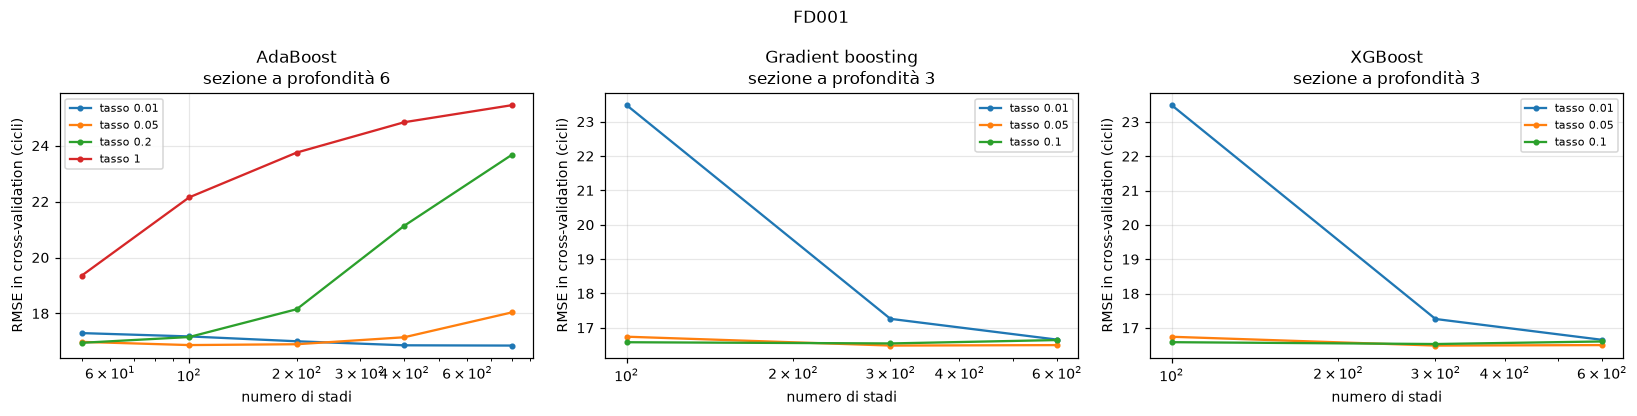

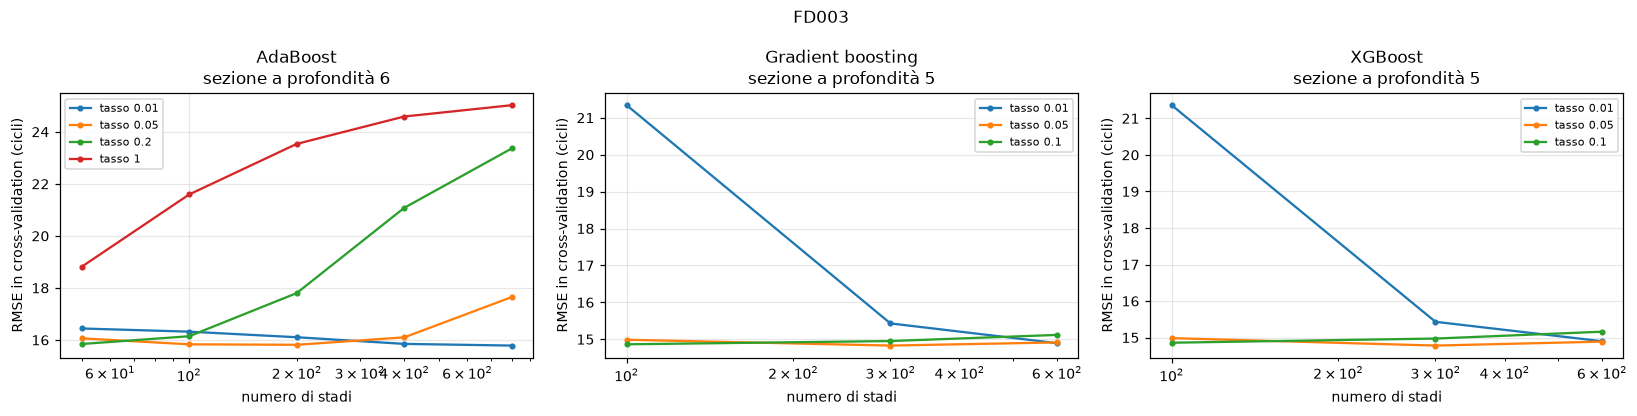

In [6]:
BOOSTING = ("adaboost", "gradient_boosting", "xgboost")
DEPTH_COLUMN = {"adaboost": "param_model__estimator__max_depth",
                "gradient_boosting": "param_model__max_depth",
                "xgboost": "param_model__max_depth"}

for subset in SUBSETS:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    for ax, model in zip(axes, BOOSTING):
        block = grid_of(subset, model)
        depth_col = DEPTH_COLUMN[model]
        chosen_depth = block.sort_values("rank_test_rmse").iloc[0][depth_col]
        section = block[block[depth_col] == chosen_depth]
        for rate, part in section.groupby("param_model__learning_rate"):
            part = part.sort_values("param_model__n_estimators")
            ax.plot(part["param_model__n_estimators"], part["mean_test_rmse"],
                    marker=".", label=f"tasso {rate:g}")
        ax.set_xscale("log")
        ax.set_xlabel("numero di stadi")
        ax.set_ylabel("RMSE in cross-validation (cicli)")
        ax.set_title(f"{LABELS[model]}\nsezione a profondità {int(chosen_depth)}")
        ax.legend(fontsize=7)
    fig.suptitle(subset)
    save(fig, f"{subset}_curve_griglie_boosting")
    plt.show()

In [7]:
rows = []
for subset in SUBSETS:
    for model in MODELS:
        block = grids[subset].query("model == @model")
        if not len(block):
            continue
        best = block["mean_test_rmse"].min()
        rows.append({
            "sottoinsieme": subset,
            "modello": LABELS[model],
            "configurazioni": len(block),
            "punteggi_distinti": int(block["mean_test_rmse"].round(6).nunique()),
            "rmse_minimo": best,
            "rmse_massimo": block["mean_test_rmse"].max(),
            "escursione_griglia": block["mean_test_rmse"].max() - best,
            "configurazioni_entro_un_ciclo": int((block["mean_test_rmse"] <= best + 1.0).sum()),
        })
piattezza = pd.DataFrame(rows)
piattezza.to_csv(TABLES_DIR / "piattezza_griglie_alberi.csv", index=False)
piattezza

,sottoinsieme,modello,configurazioni,punteggi_distinti,rmse_minimo,rmse_massimo,escursione_griglia,configurazioni_entro_un_ciclo
0,FD001,Albero di regressione potato,27,25,18.364941,41.679004,23.314063,6
1,FD001,Foresta casuale,15,15,16.426880,16.712495,0.285615,15
2,FD001,AdaBoost,100,92,16.852405,29.377703,12.525298,30
3,FD001,Gradient boosting,36,36,16.483751,24.883608,8.399857,31
4,FD001,XGBoost,36,36,16.485607,24.899430,8.413823,31
5,FD003,Albero di regressione potato,27,25,17.059958,40.724686,23.664728,8
6,FD003,Foresta casuale,15,15,14.923077,15.300852,0.377775,15
7,FD003,AdaBoost,100,91,15.787178,27.404820,11.617643,20
8,FD003,Gradient boosting,36,36,14.831171,24.031797,9.200625,28
9,FD003,XGBoost,36,36,14.781957,24.037984,9.256027,28


La colonna dei punteggi distinti serve a leggere una proprietà della griglia dell'albero. La
penalizzazione ha una sequenza propria dei dati, fatta dei valori in cui la potatura cambia
effettivamente: fra due valori consecutivi di quella sequenza l'albero resta lo stesso, e più
punti della griglia fissata a priori producono lo stesso modello. Punteggi distinti in numero
inferiore alle configurazioni misurano quanti alberi diversi la griglia abbia effettivamente
realizzato, e dicono se la sua risoluzione sia sufficiente. Sugli altri modelli la stessa colonna
non ha questo significato e coincide di norma con il numero di configurazioni.

La curva dell'albero ha la forma attesa di una potatura: piatta a penalizzazione piccola, dove
l'albero è quasi quello cresciuto per intero, poi un minimo, poi una salita ripida quando la
potatura arriva a tagliare struttura utile e infine il valore dell'albero ridotto alla sola radice,
che coincide con la predizione costante. Il tratteggio dell'albero non potato mostra quanto la
potatura valga: è la distanza fra una funzione con migliaia di foglie, adattata al rumore, e la
stessa dopo la penalizzazione.

Sulla foresta le due curve dicono cose diverse. La frazione di variabili candidate governa la
decorrelazione fra alberi e ha un minimo interno, che è il compromesso fra alberi meno correlati
e alberi individualmente peggiori. Il valore 1,0 su quell'asse è la foresta senza decorrelazione,
cioè il bagging, che il confronto contiene già come modello a sé: la distanza fra l'estremo
destro della curva e il suo minimo è l'effetto della decorrelazione misurato dentro un modello
solo. La dimensione minima della foglia sposta le curve poco, il che indica che la crescita
completa degli alberi non è il problema quando le predizioni vengono mediate.

Sui modelli per addizione le curve mostrano il compromesso proprio del boosting: a tasso alto
l'errore risale al crescere degli stadi, perché il modello continua ad adattarsi oltre il segnale;
a tasso basso serve un numero di stadi più alto per arrivare allo stesso punto. Il prodotto fra
tasso e numero di stadi è approssimativamente ciò che conta, e questo rende la griglia
ridondante lungo una direzione.

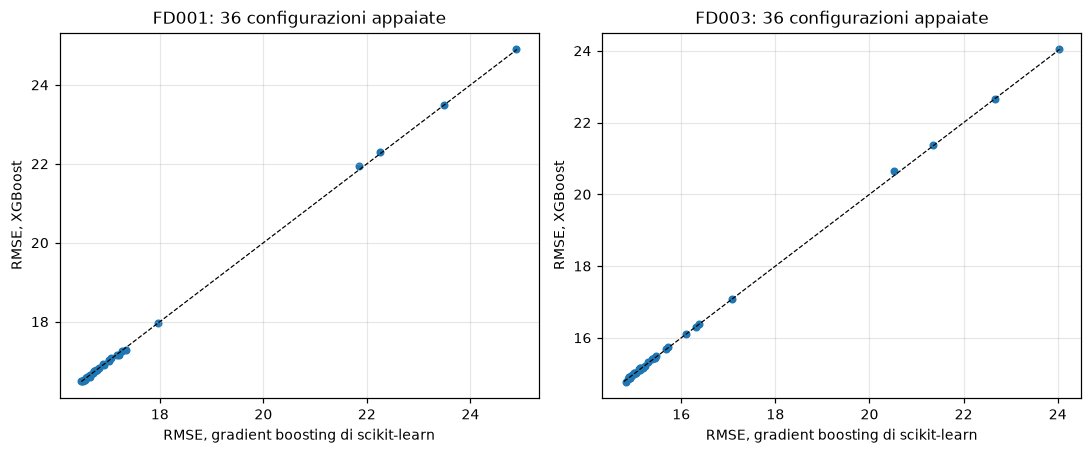

,sottoinsieme,configurazioni_appaiate,scarto_medio_cicli,scarto_massimo_cicli,ricerca_sklearn_secondi,ricerca_xgboost_secondi,rapporto_tempi
0,FD001,36,-0.002480,0.097507,439.620324,19.97449,22.009089
1,FD003,36,0.007097,0.115444,559.065956,19.38279,28.843420


In [8]:
# Le due implementazioni di gradient boosting hanno ricevuto la stessa griglia, sugli stessi assi
# e sugli stessi valori: le 36 configurazioni sono confrontabili una a una.
keys = ["param_model__n_estimators", "param_model__learning_rate", "param_model__max_depth"]
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(10, 4.2))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    left = grid_of(subset, "gradient_boosting")[keys + ["mean_test_rmse"]]
    right = grid_of(subset, "xgboost")[keys + ["mean_test_rmse"]]
    paired = left.merge(right, on=keys, suffixes=("_sklearn", "_xgboost"))
    ax.scatter(paired["mean_test_rmse_sklearn"], paired["mean_test_rmse_xgboost"], s=18)
    lo = min(paired["mean_test_rmse_sklearn"].min(), paired["mean_test_rmse_xgboost"].min())
    hi = max(paired["mean_test_rmse_sklearn"].max(), paired["mean_test_rmse_xgboost"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("RMSE, gradient boosting di scikit-learn")
    ax.set_ylabel("RMSE, XGBoost")
    ax.set_title(f"{subset}: {len(paired)} configurazioni appaiate")
save(fig, "confronto_implementazioni_boosting")
plt.show()

rows = []
for subset in SUBSETS:
    left = grid_of(subset, "gradient_boosting")[keys + ["mean_test_rmse"]]
    right = grid_of(subset, "xgboost")[keys + ["mean_test_rmse"]]
    paired = left.merge(right, on=keys, suffixes=("_sklearn", "_xgboost"))
    delta = paired["mean_test_rmse_xgboost"] - paired["mean_test_rmse_sklearn"]
    tempi = comparison[subset].set_index("model")["search_seconds"]
    rows.append({
        "sottoinsieme": subset,
        "configurazioni_appaiate": len(paired),
        "scarto_medio_cicli": delta.mean(),
        "scarto_massimo_cicli": delta.abs().max(),
        "ricerca_sklearn_secondi": tempi["gradient_boosting"],
        "ricerca_xgboost_secondi": tempi["xgboost"],
        "rapporto_tempi": tempi["gradient_boosting"] / max(tempi["xgboost"], 1e-9),
    })
implementazioni = pd.DataFrame(rows)
implementazioni.to_csv(TABLES_DIR / "confronto_implementazioni_boosting.csv", index=False)
implementazioni

Le due implementazioni di gradient boosting hanno ricevuto griglie identiche, quindi ogni
configurazione esiste in due esemplari e i punti della figura sono coppie. Ciò che il confronto
isola non è quale sia il modello migliore, ma quanto la scelta dell'implementazione cambi il
risultato a parità di tutto il resto.

I punti cadono sulla bisettrice, con scarti dell'ordine del centesimo di ciclo, mentre il tempo di
ricerca differisce di un fattore che la tabella riporta e che è di due ordini di grandezza. La
lettura è che la differenza fra le due righe della tabella di confronto è interamente
computazionale e non statistica.

Uno scarto residuo esiste e ha una causa nota: l'implementazione esterna applica per impostazione
predefinita una regolarizzazione sui pesi delle foglie che scikit-learn non ha. Non è stata
azzerata per non allontanare il modello dalla forma in cui il laboratorio lo usa, ed è il motivo
per cui i punti non giacciono esattamente sulla bisettrice.

## 3. Quanti alberi servono agli insiemi per aggregazione

Il numero di alberi di bagging e foresta non è stato cercato in griglia ma fissato a 300. La
ragione è che non governa un compromesso: l'errore di un insieme per aggregazione decresce in
valore atteso in modo monotono nel numero di alberi e satura, quindi è un parametro di precisione
della media. Metterlo in griglia avrebbe fatto selezionare sistematicamente il valore massimo e
avrebbe richiesto di estendere la griglia senza un criterio di arresto.

La curva che segue è la verifica di quella scelta, misurata prima di fissare le griglie su una
sola partizione e facendo crescere lo stesso insieme invece di ricostruirlo a ogni punto.

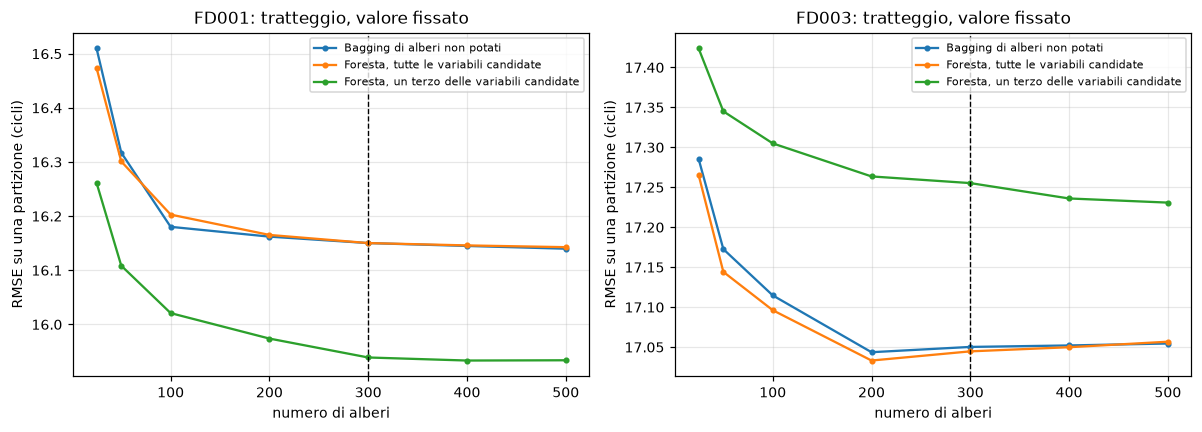

,sottoinsieme,insieme,rmse_100,rmse_300,rmse_500,variazione_300_500
0,FD001,Bagging di alberi non potati,16.180322,16.150311,16.139910,-0.010401
1,FD001,"Foresta, tutte le variabili candidate",16.202938,16.150324,16.142750,-0.007574
2,FD001,"Foresta, un terzo delle variabili candidate",16.020930,15.938965,15.933815,-0.005150
3,FD003,Bagging di alberi non potati,17.114781,17.050299,17.054575,0.004276
4,FD003,"Foresta, tutte le variabili candidate",17.096258,17.044750,17.056824,0.012074
5,FD003,"Foresta, un terzo delle variabili candidate",17.304995,17.255299,17.230875,-0.024423


In [9]:
fig, axes = plt.subplots(1, len(SUBSETS), figsize=(11, 4))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    for key, part in saturation[subset].groupby("key"):
        part = part.sort_values("n_estimators")
        ax.plot(part["n_estimators"], part["rmse"], marker=".",
                label=part["label"].iloc[0])
    ax.axvline(300, color="black", linewidth=0.9, linestyle="--")
    ax.set_xlabel("numero di alberi")
    ax.set_ylabel("RMSE su una partizione (cicli)")
    ax.set_title(f"{subset}: tratteggio, valore fissato")
    ax.legend(fontsize=7)
save(fig, "saturazione_insiemi_alberi")
plt.show()

rows = []
for subset in SUBSETS:
    block = saturation[subset]
    for key, part in block.groupby("key"):
        part = part.set_index("n_estimators")["rmse"]
        rows.append({
            "sottoinsieme": subset,
            "insieme": block.query("key == @key")["label"].iloc[0],
            "rmse_100": part.get(100, np.nan),
            "rmse_300": part.get(300, np.nan),
            "rmse_500": part.get(500, np.nan),
            "variazione_300_500": part.get(500, np.nan) - part.get(300, np.nan),
        })
satura = pd.DataFrame(rows)
satura.to_csv(TABLES_DIR / "saturazione_insiemi_alberi.csv", index=False)
satura

Le curve sono piatte molto prima del valore fissato. Fra 300 e 500 alberi la variazione è di
centesimi di ciclo, contro una dispersione fra fold superiore all'unità, e su FD003 non è nemmeno
monotona: la decrescita è monotona in valore atteso, non su una singola partizione, e oltre le
poche centinaia di alberi ciò che si osserva è rumore della partizione e non miglioramento del
modello. Il valore fissato è quindi confermato, e più alberi avrebbero comprato solo tempo di
calcolo.

La curva contiene anche un controllo di correttezza. Il bagging e la foresta con tutte le variabili
candidate sono lo stesso modello sotto due classi diverse della libreria, e le loro curve si
sovrappongono a ogni punto: se divergessero, la differenza andrebbe cercata nella composizione
delle due pipeline e non nei modelli. È l'analogo della coincidenza fra regressione sulle
componenti principali a componenti complete e minimi quadrati, verificata nel primo blocco.

La distanza fra la foresta decorrelata e le altre due curve, sulla stessa partizione, è l'effetto
della decorrelazione. Va notato che il suo segno non è lo stesso sui due sottoinsiemi, mentre nel
confronto sulle 15 partizioni la foresta selezionata risulta davanti al bagging su entrambi:
questa figura riguarda una sola partizione e una sola configurazione, e non è una misura di
prestazione. È l'esempio più diretto, dentro questo blocco, del motivo per cui il protocollo non
riporta numeri di una partizione sola.

## 4. La struttura dell'albero potato

L'albero è l'unico modello del blocco che si legge guardandone la forma: è una sequenza di
domande su una variabile alla volta, e ogni foglia è una previsione costante per tutte le
osservazioni che vi arrivano. Gli insiemi ne contengono centinaia e non hanno una struttura da
mostrare.

L'albero caricato qui è quello riaddestrato sull'intera parte di addestramento con la
penalizzazione selezionata, cioè lo stesso da cui provengono le importanze per riduzione di
impurità della sezione successiva. La figura ne mostra i primi livelli: l'albero intero ha decine
di foglie e sarebbe illeggibile.

Le soglie sono nelle unità standardizzate della pipeline. La tabella che segue le riporta anche
nelle unità originali delle variabili, invertendo la trasformazione con i parametri dello
standardizzatore adattato.

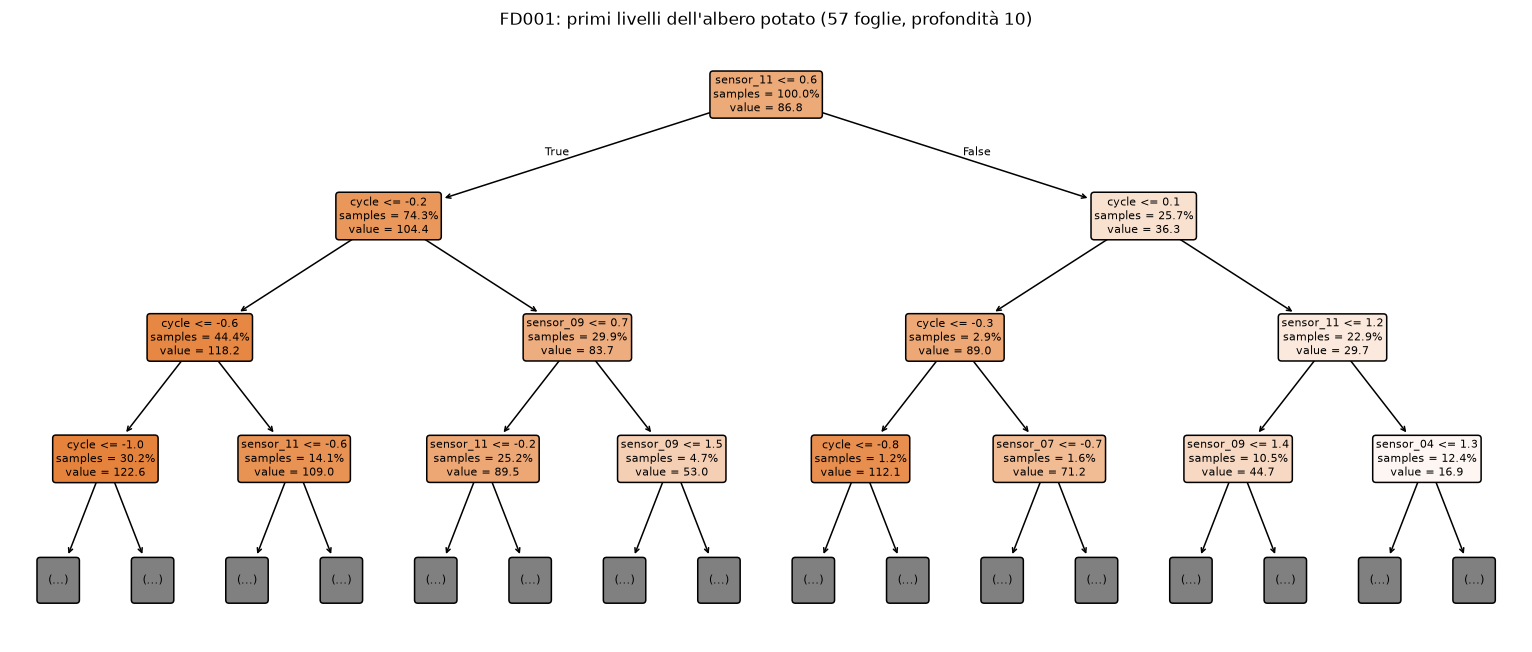

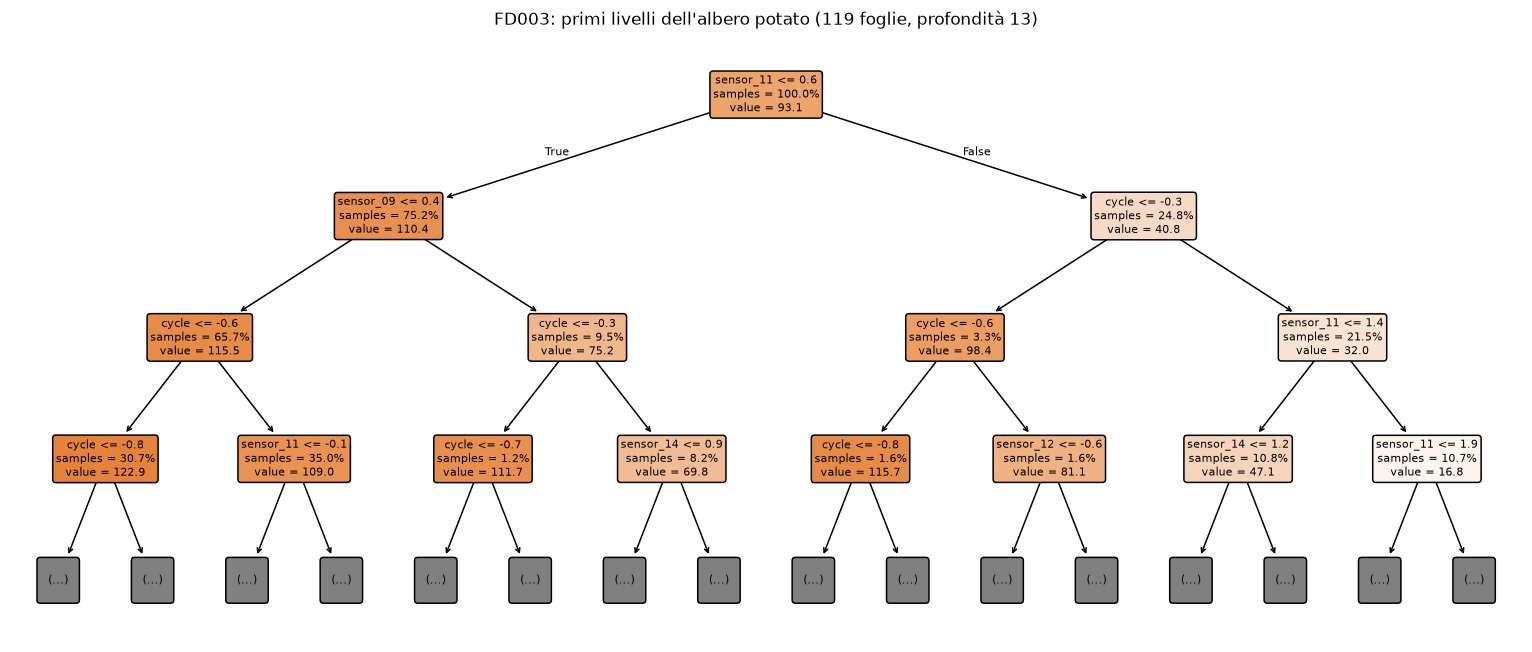

In [10]:
trees = {}
for subset in SUBSETS:
    pipeline = joblib.load(TREE_DIR / f"{subset}_pruned_tree.joblib")
    trees[subset] = pipeline

for subset in SUBSETS:
    pipeline = trees[subset]
    model = pipeline.named_steps["model"]
    features = list(pipeline.named_steps["scale"].feature_names_in_)
    fig, ax = plt.subplots(figsize=(14, 6))
    plot_tree(model, max_depth=3, feature_names=features, filled=True, impurity=False,
              proportion=True, rounded=True, precision=1, fontsize=7, ax=ax)
    ax.set_title(f"{subset}: primi livelli dell'albero potato "
                 f"({model.get_n_leaves()} foglie, profondità {model.get_depth()})")
    save(fig, f"{subset}_struttura_albero_potato")
    plt.show()

In [11]:
def split_table(pipeline, max_depth=3):
    """Divisioni dell'albero fino a una profondità, con soglie nelle unità originali."""
    model = pipeline.named_steps["model"]
    scaler = pipeline.named_steps["scale"]
    features = np.asarray(scaler.feature_names_in_)
    tree = model.tree_

    rows = []
    stack = [(0, 0)]
    while stack:
        node, depth = stack.pop()
        if tree.children_left[node] == -1 or depth > max_depth:
            continue
        index = tree.feature[node]
        rows.append({
            "profondita": depth,
            "variabile": features[index],
            "soglia_standardizzata": tree.threshold[node],
            "soglia_originale": tree.threshold[node] * scaler.scale_[index] + scaler.mean_[index],
            "quota_osservazioni": tree.n_node_samples[node] / tree.n_node_samples[0],
            "previsione_nodo": tree.value[node].ravel()[0],
        })
        stack.append((tree.children_left[node], depth + 1))
        stack.append((tree.children_right[node], depth + 1))
    return pd.DataFrame(rows).sort_values(["profondita", "quota_osservazioni"],
                                          ascending=[True, False])


rows = []
for subset in SUBSETS:
    block = split_table(trees[subset])
    block.insert(0, "sottoinsieme", subset)
    rows.append(block)
divisioni = pd.concat(rows, ignore_index=True)
divisioni.to_csv(TABLES_DIR / "divisioni_albero_potato.csv", index=False)
divisioni

,sottoinsieme,profondita,variabile,soglia_standardizzata,soglia_originale,quota_osservazioni,previsione_nodo
0,FD001,0,sensor_11,0.575975,47.695000,1.000000,86.829286
1,FD001,1,cycle,-0.193205,95.500000,0.742523,104.364906
2,FD001,1,cycle,0.068121,113.500000,0.257477,36.259224
3,FD001,2,cycle,-0.643268,64.500000,0.443944,118.238345
4,FD001,2,sensor_09,0.706993,9080.855000,0.298580,83.737175
5,FD001,2,sensor_11,1.249928,47.875000,0.228830,29.661724
6,FD001,2,cycle,-0.338387,85.500001,0.028646,88.961083
7,FD001,3,cycle,-0.962667,42.500001,0.302457,122.554968
8,FD001,3,sensor_11,-0.247746,47.475000,0.251563,89.489981
9,FD001,3,sensor_11,-0.584722,47.385000,0.141486,109.010620


La prima divisione è quella che separa di più le osservazioni e va letta insieme alla censura del
target. Il target è costante a 125 cicli per tutta la prima fase di vita di ogni motore, quindi
esiste una soglia che separa le traiettorie ancora nella zona piatta da quelle che hanno iniziato a
degradare, e l'albero la trova.

La quota di osservazioni di ciascun nodo dice quanto l'albero sia bilanciato. Nodi che raccolgono
una frazione piccola di righe producono previsioni stimate su poche osservazioni, e sono la parte
di albero che la potatura ha il compito di rimuovere: la profondità raggiunta dopo la potatura,
riportata nel titolo della figura, è molto inferiore a quella dell'albero cresciuto per intero,
che su questa matrice avrebbe circa una foglia per riga di addestramento.

Le previsioni dei nodi sono in cicli e permettono di leggere l'albero come una regola: seguendo un
percorso dalla radice a una foglia si ottiene la vita residua che il modello attribuisce a un
motore con quelle caratteristiche. È l'unico modello del confronto che ammette questa lettura
diretta, ed è la ragione per cui resta in tabella nonostante sia il peggiore della famiglia.

## 5. Quali variabili pesano, secondo due misure che non coincidono

I modelli ad albero ammettono due letture dell'importanza delle variabili, che misurano cose
diverse e vanno tenute distinte.

La riduzione di impurità è calcolata durante la costruzione: somma quanto ciascuna variabile ha
ridotto l'errore quadratico nei nodi in cui è stata usata, pesando per le osservazioni che li
attraversano. È gratuita, perché è un sottoprodotto dell'addestramento, ed è distorta verso le
variabili con molti valori distinti, che offrono più punti di taglio fra cui scegliere il migliore.
Su questo dataset la distorsione ha un bersaglio preciso: il numero di ciclo è un conteggio e
assume più valori distinti di qualunque lettura di sensore. Inoltre è calcolata sui dati di
addestramento.

L'importanza per permutazione misura invece di quanto peggiora l'errore quando i valori di una
variabile vengono mescolati fra le righe, ed è calcolata su dati non usati per l'addestramento:
qui la parte di verifica di ciascuna delle cinque partizioni del seme di ricerca, con il modello
riaddestrato sulla parte di addestramento della stessa partizione. L'insieme di verifica ufficiale,
che è dove il laboratorio la calcola, resta chiuso fino alla chiusura della graduatoria. Il valore
è in cicli: è l'aumento della metrica di riferimento.

Le due misure sono riportate entrambe, e il confronto fra i loro ordinamenti è esso stesso un
risultato.

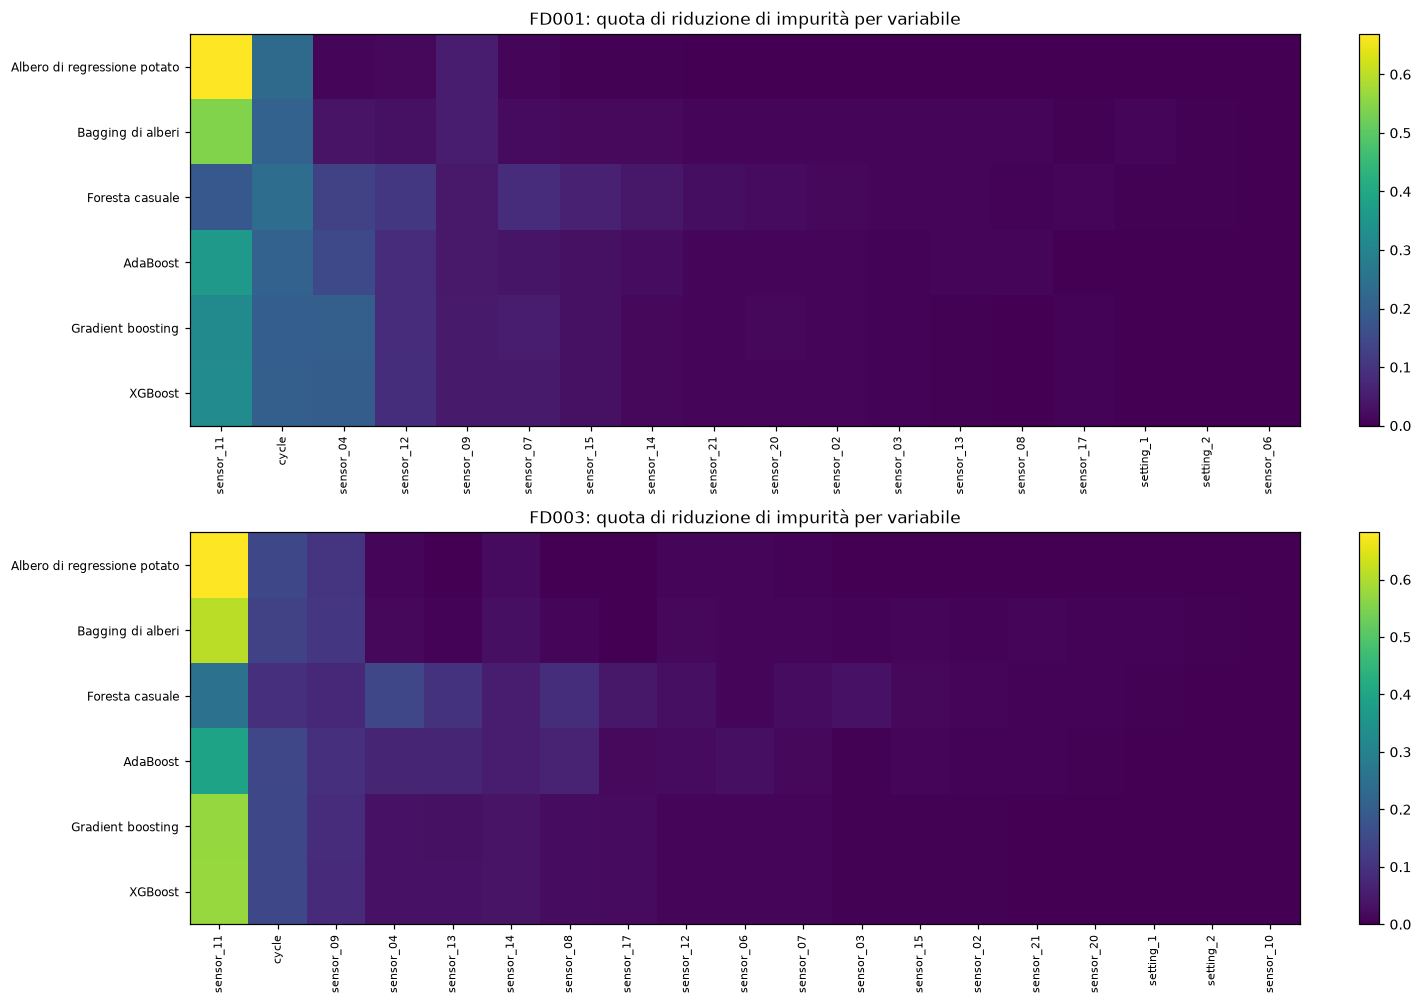

In [12]:
fig, axes = plt.subplots(len(SUBSETS), 1, figsize=(13, 4.6 * len(SUBSETS)))
for ax, subset in zip(np.atleast_1d(axes), SUBSETS):
    wide = importances[subset].pivot(index="model", columns="feature", values="importance")
    wide = wide.reindex(index=[m for m in MODELS if m in wide.index])
    wide = wide[wide.mean().sort_values(ascending=False).index]
    image = ax.imshow(wide.to_numpy(), aspect="auto", cmap="viridis")
    ax.set_xticks(range(wide.shape[1]))
    ax.set_xticklabels(wide.columns, rotation=90, fontsize=7)
    ax.set_yticks(range(wide.shape[0]))
    ax.set_yticklabels([LABELS[m] for m in wide.index], fontsize=8)
    ax.grid(False)
    ax.set_title(f"{subset}: quota di riduzione di impurità per variabile")
    fig.colorbar(image, ax=ax, fraction=0.02)
save(fig, "importanze_impurita_alberi")
plt.show()

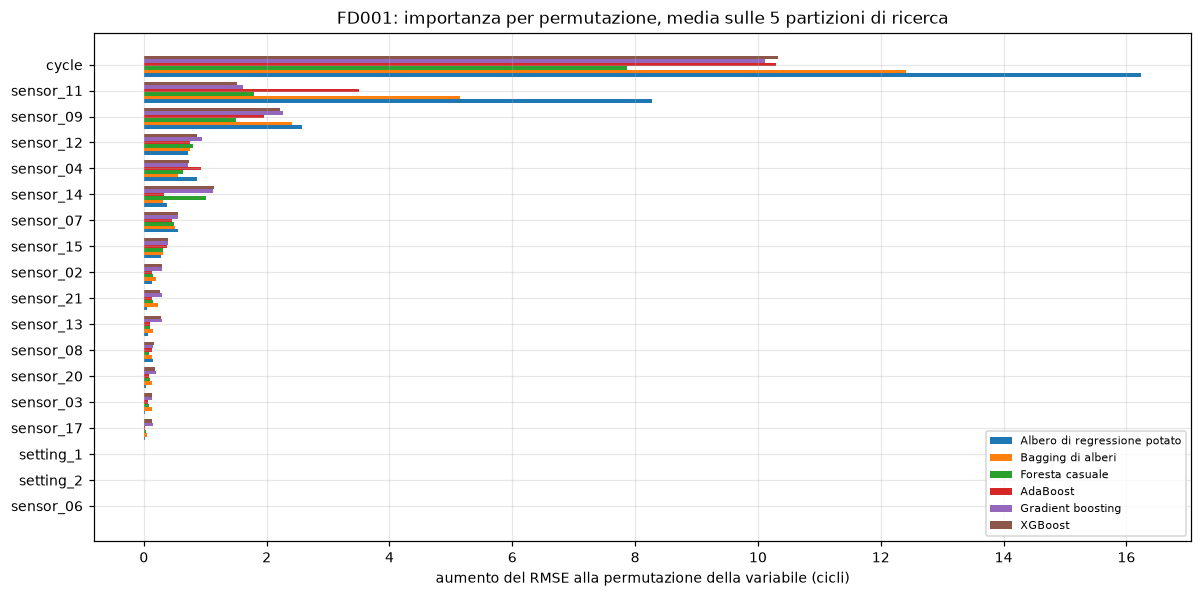

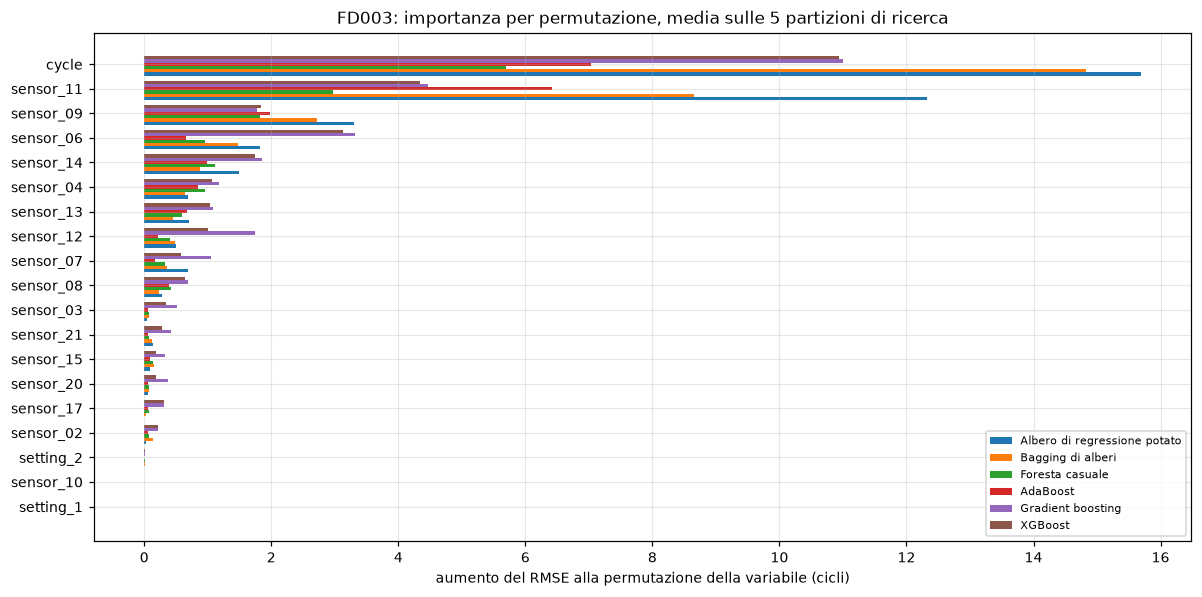

In [13]:
for subset in SUBSETS:
    wide = permutation[subset].pivot(index="feature", columns="model", values="importance_mean")
    wide = wide[[m for m in MODELS if m in wide.columns]]
    order = wide.mean(axis=1).sort_values().index
    wide = wide.loc[order]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    y = np.arange(len(wide))
    height = 0.8 / wide.shape[1]
    for i, model in enumerate(wide.columns):
        ax.barh(y + (i - wide.shape[1] / 2) * height, wide[model], height=height,
                label=LABELS[model])
    ax.set_yticks(y)
    ax.set_yticklabels(wide.index)
    ax.set_xlabel("aumento del RMSE alla permutazione della variabile (cicli)")
    ax.set_title(f"{subset}: importanza per permutazione, media sulle 5 partizioni di ricerca")
    ax.legend(fontsize=7)
    save(fig, f"{subset}_importanze_permutazione")
    plt.show()

In [14]:
rows = []
for subset in SUBSETS:
    for model in MODELS:
        impurity = importances[subset].query("model == @model").set_index("feature")["importance"]
        perm = permutation[subset].query("model == @model").set_index("feature")["importance_mean"]
        common = impurity.index.intersection(perm.index)
        share = impurity.sort_values(ascending=False)
        cumulative = share.cumsum()
        rows.append({
            "sottoinsieme": subset,
            "modello": LABELS[model],
            "quota_impurita_ciclo": impurity.get("cycle", np.nan),
            "permutazione_ciclo_cicli": perm.get("cycle", np.nan),
            "variabili_per_90_percento": int((cumulative < 0.90).sum() + 1),
            "variabili_mai_usate": int((impurity <= 0).sum()),
            "concordanza_ordinamenti": impurity[common].rank(ascending=False).corr(
                perm[common].rank(ascending=False), method="spearman"),
        })
letture = pd.DataFrame(rows)
letture.to_csv(TABLES_DIR / "importanze_confronto_misure.csv", index=False)
letture

,sottoinsieme,modello,quota_impurita_ciclo,permutazione_ciclo_cicli,variabili_per_90_percento,variabili_mai_usate,concordanza_ordinamenti
0,FD001,Albero di regressione potato,0.232110,16.244274,2,5,0.979704
1,FD001,Bagging di alberi,0.209446,12.411286,7,0,0.966976
2,FD001,Foresta casuale,0.238563,7.871093,9,0,0.929825
3,FD001,AdaBoost,0.211202,10.287475,7,1,0.975232
4,FD001,Gradient boosting,0.200322,10.110774,6,1,0.902993
5,FD001,XGBoost,0.201445,10.318791,6,1,0.915377
6,FD003,Albero di regressione potato,0.146662,15.698735,3,5,0.934421
7,FD003,Bagging di alberi,0.131003,14.823892,6,0,0.945614
8,FD003,Foresta casuale,0.091696,5.703212,10,0,0.787719
9,FD003,AdaBoost,0.144103,7.028846,8,0,0.942105


Il numero di ciclo domina entrambe le misure su tutti i modelli, ed è il risultato atteso: su
traiettorie che arrivano tutte al guasto la vita residua è per costruzione la differenza fra
durata e ciclo corrente, quindi una parte della capacità predittiva di qualunque modello proviene
da un conteggio e non dalla lettura del degrado. È esattamente il motivo per cui il confronto
contiene una baseline che usa il solo numero di ciclo, e il divario fra quella baseline e i modelli
misura ciò che i sensori aggiungono.

La quantità che merita attenzione è come il peso del numero di ciclo cambi fra modelli sotto la
seconda misura. Passando dal bagging alla foresta l'aumento di errore alla sua permutazione si
riduce in modo netto su entrambi i sottoinsiemi. La lettura non è che la foresta usi meno il
numero di ciclo: la riduzione di impurità mostra che continua a usarlo. È che, obbligando ogni
divisione a scegliere fra un terzo delle variabili, la foresta costruisce percorsi ridondanti, e
mescolare una variabile lascia al modello l'informazione che le altre portano al suo posto. È la
decorrelazione resa visibile su una quantità misurata, ed è anche la ragione per cui
l'importanza per permutazione non va letta come una prova che una variabile sia inutile: fra
variabili correlate la misura si ripartisce e in parte si annulla.

La colonna delle variabili necessarie a coprire il novanta per cento della riduzione di impurità
descrive quanto ciascun modello concentri il peso. L'albero singolo, avendo poche decine di
divisioni, ne concentra molto e lascia alcune variabili mai usate; gli insiemi lo distribuiscono,
perché centinaia di alberi finiscono per interrogare tutte le variabili almeno una volta. La
colonna del numero di variabili attive della tabella di confronto è la stessa informazione in
forma più grossolana.

La concordanza fra i due ordinamenti dice quanto la lettura dipenda dalla misura scelta. Dove è
alta le due misure raccontano la stessa storia; dove è bassa nessuno dei due ordinamenti va
presentato come l'importanza delle variabili, e va riportata la distinzione.

## 6. Diagnostica dell'esperimento

La tabella raccoglie ciò che è successo durante la ricerca su griglia e che non compare nei
punteggi: quante configurazioni sono state valutate, se la configurazione selezionata cada su un
estremo della griglia, quante configurazioni non siano state valutabili, quante mancate convergenze
si siano verificate.

È la parte che rende verificabile il resto. Un estremo selezionato significa che la griglia
potrebbe tagliare fuori configurazioni migliori e impone di estenderla e rieseguire la ricerca. Una
configurazione non valutabile sparirebbe altrimenti in silenzio, perché la ricerca su griglia le
assegna un punteggio non definito e prosegue riportando un vincitore regolare.

In [15]:
rows = []
for subset in SUBSETS:
    block = diagnostics[subset].copy()
    block.insert(0, "sottoinsieme", subset)
    rows.append(block)
diagnostica = pd.concat(rows, ignore_index=True)
colonne = ["sottoinsieme", "model", "n_configurations", "boundary", "failed_configurations",
           "convergence_warnings", "n_leaves", "depth", "search_seconds"]
diagnostica = diagnostica[[c for c in colonne if c in diagnostica.columns]]
diagnostica.to_csv(TABLES_DIR / "diagnostica_blocco_alberi.csv", index=False)

print("configurazioni non valutabili in tutto il blocco:",
      int(diagnostica["failed_configurations"].fillna(0).sum()))
print("mancate convergenze in tutto il blocco:",
      int(diagnostica["convergence_warnings"].fillna(0).sum()))
diagnostica

configurazioni non valutabili in tutto il blocco: 0
mancate convergenze in tutto il blocco: 0


,sottoinsieme,model,n_configurations,boundary,failed_configurations,convergence_warnings,n_leaves,depth,search_seconds
0,FD001,tree,27.0,NaN,0.0,0.0,57.0,10.0,7.620543
1,FD001,bagging,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FD001,random_forest,15.0,NaN,0.0,0.0,NaN,NaN,133.480959
3,FD001,adaboost,100.0,"model__n_estimators=massimo, model__learning_r...",0.0,0.0,NaN,NaN,784.297473
4,FD001,gradient_boosting,36.0,NaN,0.0,0.0,NaN,NaN,439.620324
5,FD001,xgboost,36.0,NaN,0.0,0.0,NaN,NaN,19.974490
6,FD003,tree,27.0,NaN,0.0,0.0,119.0,13.0,9.155324
7,FD003,bagging,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,FD003,random_forest,15.0,NaN,0.0,0.0,NaN,NaN,185.403482
9,FD003,adaboost,100.0,"model__n_estimators=massimo, model__learning_r...",0.0,0.0,NaN,NaN,1012.389736


In [16]:
# Verifica sul bordo del numero di stadi di AdaBoost. L'implementazione interrompe il boosting se
# uno stadio supera la metà dell'errore relativo: in quel caso le configurazioni con più stadi
# darebbero punteggi identici a quelle con meno stadi, e il bordo sarebbe apparente e non reale.
rows = []
for subset in SUBSETS:
    block = grid_of(subset, "adaboost")
    pivot = block.pivot_table(index=["param_model__learning_rate",
                                     "param_model__estimator__max_depth"],
                              columns="param_model__n_estimators",
                              values="mean_test_rmse")
    largest, second = sorted(pivot.columns)[-1], sorted(pivot.columns)[-2]
    identical = np.isclose(pivot[largest], pivot[second], rtol=0, atol=1e-9).sum()
    rows.append({
        "sottoinsieme": subset,
        "coppie_confrontate": len(pivot),
        f"punteggi_identici_fra_{int(second)}_e_{int(largest)}_stadi": int(identical),
        "scarto_mediano_cicli": float((pivot[second] - pivot[largest]).median()),
    })
pd.DataFrame(rows)

,sottoinsieme,coppie_confrontate,punteggi_identici_fra_400_e_800_stadi,scarto_mediano_cicli
0,FD001,20,4,-0.552256
1,FD003,20,4,-0.469386


Le configurazioni non valutabili e le mancate convergenze sono assenti: nessun modello di questo
blocco richiede una stima iterativa che possa non convergere, e nessuna trasformazione può fallire
su valori fuori dall'intervallo osservato in addestramento, come accadeva invece alla base spline
di grado nullo nel blocco precedente.

Restano selezionati due estremi, entrambi su AdaBoost, e sono un limite dichiarato e non una griglia
da estendere. La griglia di quel modello è già stata estesa due volte secondo la regola fissata a
priori: la profondità dell'albero di base è passata da 4 a 5 e poi a 6, il numero di stadi da 400
a 800, e a ogni estensione la ricerca ha selezionato di nuovo l'angolo.

Il motivo sta nell'algoritmo. In AdaBoost.R2 il peso di ciascuno stadio è il tasso di apprendimento
moltiplicato per il logaritmo dell'inverso dell'errore relativo, quindi il tasso riscala tutti i
pesi della stessa costante; l'aggregazione è una mediana pesata, che individua lo stadio in cui la
somma cumulata dei pesi supera metà del totale, ed è perciò invariante a un riscalamento comune.
Il tasso non agisce sulla predizione attraverso i pesi degli stadi, ma soltanto attraverso
l'aggiornamento dei pesi delle osservazioni. Quando tende a zero il ripesaggio si annulla, ogni
stadio viene adattato su un campione bootstrap a pesi uniformi e le predizioni sono combinate per
mediana: quel limite è il bagging, che il confronto contiene già con una riga propria. Il bordo
inferiore del tasso è quindi strutturale nello stesso senso della potatura nulla, e l'estensione
porterebbe a un modello noto invece che a uno spazio nuovo, come accade a Elastic Net verso il lato
di Ridge.

La catena delle estensioni è stata chiusa quando l'ultima ha spostato il modello di meno della
dispersione fra fold su entrambi i sottoinsiemi: sotto quella soglia la regola di lettura del
progetto non ordina due risultati, quindi continuare a estendere inseguirebbe differenze che il
protocollo dichiara illeggibili. La conseguenza va dichiarata: AdaBoost è riportato al miglior
valore della griglia esplorata e non al suo ottimo, e la direzione di miglioramento punta verso la
sua degenerazione in un modello già presente nel confronto. Il numero a cui tenderebbe è quindi
già in tabella, ed è quello del bagging.

La verifica sul numero di stadi esclude che quel bordo sia apparente: se l'implementazione avesse
interrotto il boosting in anticipo, le configurazioni a 400 e a 800 stadi avrebbero punteggi
identici, e non li hanno.

## 7. Sintesi del blocco

La famiglia ad albero non produce un vincitore. I cinque insiemi stanno entro una frazione di
dispersione l'uno dall'altro su entrambi i sottoinsiemi e non sono ordinabili sotto questo
protocollo; l'unico modello che si stacca è l'albero singolo, indietro di più di una dispersione.
Ciò che il blocco misura in modo netto è quindi il valore dell'aggregazione, non la superiorità
di un modo di aggregare.

Il confronto con i blocchi precedenti è asimmetrico fra i due sottoinsiemi, e questa è la lettura
che va tenuta ferma. Su FD003 il miglior modello ad albero supera il miglior modello non lineare di
più di una dispersione, ed è un vantaggio leggibile; su FD001 la distanza resta sotto la
dispersione, quindi su quel sottoinsieme la famiglia ad albero non batte in modo difendibile il
blocco precedente. FD003 contiene due modi di guasto invece di uno, e i modelli a soglie trovano lì
qualcosa che le espansioni additive non colgono: una relazione che cambia forma fra sottopopolazioni
di traiettorie è esattamente ciò che una partizione ricorsiva rappresenta bene e una somma di
funzioni lisce per variabile no.

La decorrelazione della foresta rispetto al bagging va nella direzione attesa su entrambi i
sottoinsiemi ma vale una frazione di dispersione: è visibile nel segno e non nella misura del
confronto. Si legge invece bene nelle importanze per permutazione, dove il peso del numero di ciclo
cala in modo netto passando dal bagging alla foresta.

La scelta dell'implementazione di gradient boosting non cambia il risultato. Sulle 36 configurazioni
appaiate gli scarti sono dell'ordine del centesimo di ciclo, mentre i tempi differiscono di due
ordini di grandezza: è una differenza di ingegneria del software e non di metodo statistico.

Quattro limiti vanno dichiarati.

I punteggi sono ottimistici, perché la cross-validation non è annidata e la ricerca degli
iperparametri usa le stesse partizioni su cui la prestazione viene poi misurata. In questo blocco il
numero di configurazioni esplorate varia da 1 a 100 fra le righe della stessa tabella: il bagging,
che non ha iperparametri, non paga distorsione da selezione, mentre AdaBoost ne paga quanto cento
configurazioni. Il protocollo è identico per tutti, ma il confronto non è a parità di questo
fattore, e la penalizzazione implicita ricade sul modello che esplora meno.

AdaBoost è riportato su una configurazione d'angolo, quindi al miglior valore della griglia
esplorata e non al suo ottimo, per le ragioni della sezione precedente.

Il numero di alberi degli insiemi per aggregazione è fissato e non selezionato. La curva di
saturazione mostra che la scelta non è vincolante, ma resta un parametro deciso fuori dalla
ricerca.

Tutte le misure di questo notebook sono in cross-validation. Nessuna riga dell'insieme di verifica
ufficiale è stata letta, e la stima non condizionata dalle scelte del progetto arriverà solo a
graduatoria chiusa.